In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#gros_pd = pd.DataFrame()
#for nb_features in range(1,55):
#    df = pd.read_csv(f'../data/nested_CV_checker_{nb_features}_ft.csv', index_col = 0)
#    df['nb_features'] = nb_features
#    gros_pd = pd.concat([gros_pd,df.reset_index()])
#

In [28]:
from pathlib import Path
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
directory = Path("/home/slouviot/01_projects/eeg_brain_state_prediction/data/custom_envelope_caps/group_level_feature_selection")
TASK = "checker"
C = "even"
additional_info = "WithPupil"

gros_pd = pd.DataFrame()
for file in directory.iterdir():
    if file.suffix == ".csv":
        description = re.search(r"desc-\w+(?=_)", file.name).group(0)
        task = re.search(r"task-\w+(?=_)", file.name).group(0)
        subject = re.search(r"sub-\w+(?=_)", file.name).group(0)
        condition = (
        description.split("-")[1] == "CustomEnvBkFeatureSelectionAggTstats",
        task.split("-")[1] == f"{TASK}"
        )
        if all(condition):
            df = pd.read_csv(file)
            other_df = pd.read_csv(f"/home/slouviot/01_projects/eeg_brain_state_prediction/data/custom_envelope_caps/group_level_feature_selection_2/{subject}_task-{TASK}_desc-CustomEnvBk8CapsEegOnly_predictions.csv")
            #df.drop(columns = ["Unnamed: 0", "index"], inplace = True)
            #other_df.drop(columns = ["Unnamed: 0","index"], inplace = True)
            df = pd.concat([df, other_df])
            df["task"] = TASK
            df["description"] = "CustomEnvBk8CapsEegOnly"
            df.drop_duplicates(inplace=True)
            df.sort_values(by = "n_features", inplace = True)
            df.sort_values(by = ["ts_CAPS", "n_features"], inplace = True)
            df.reset_index(inplace=True, drop = True)
            df.to_csv(file, index=False)
            file.rename(file.parent/file.name.replace(
                "desc-CustomEnvBkFeatureSelectionAggTstats_predictions",
                "desc-CustomEnvBk8CapsEegOnly_predictions"
            )
            )


#another_gros_pd = pd.read_csv(f"/home/slouviot/01_projects/eeg_brain_state_prediction/data/custom_envelope_caps/sub-all_ses-all_task-{TASK}_desc-CustomEnvBk8FeatureSelection_predictions.csv")
#another_gros_pd.drop(columns = ["Unnamed: 0"], inplace = True)
#another_gros_pd = another_gros_pd[another_gros_pd["n_features"] < 10]
#gros_pd = pd.concat([gros_pd,another_gros_pd])

/tmp/ipykernel_1287825/1109784092.py:26: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, other_df])


In [31]:
pd.read_csv("/home/slouviot/01_projects/eeg_brain_state_prediction/data/custom_envelope_caps/group_level_feature_selection/sub-02_task-rest_desc-CustomEnvBk8CapsEegOnly_predictions.csv")

,subject,session,ts_CAPS,pearson_r,frequency_Hz,electrode,n_features,task,description
0,2,1,CAP1,0.332368,[3],[60],1,rest,CustomEnvBk8Caps
1,2,1,CAP2,0.371919,[3],[60],1,rest,CustomEnvBk8Caps
2,2,1,CAP3,0.264992,[8],[58],1,rest,CustomEnvBk8Caps
3,2,1,CAP4,0.251495,[8],[58],1,rest,CustomEnvBk8Caps
4,2,1,CAP5,-0.017727,[14],[25],1,rest,CustomEnvBk8Caps
...,...,...,...,...,...,...,...,...,...
395,2,1,CAP4,0.182845,[ 8 8 9 8 7 10 7 8 7 7 19 8 11 7 9 ...,[58 9 58 15 9 58 58 44 44 19 9 8 58 8 9 ...,50,rest,CustomEnvBk8Caps
396,2,1,CAP5,0.250415,[14 14 15 13 16 15 14 12 11 14 12 11 13 13 2 ...,[25 53 53 25 53 10 10 11 11 46 52 52 46 40 60 ...,50,rest,CustomEnvBk8Caps
397,2,1,CAP6,0.261072,[16 14 15 13 14 14 12 11 15 12 14 11 13 15 3 ...,[53 25 53 25 53 10 11 11 10 52 46 52 46 25 16 ...,50,rest,CustomEnvBk8Caps
398,2,1,CAP7,0.337782,[ 3 2 2 12 11 10 2 3 2 2 3 4 3 2 3 ...,[16 59 1 52 52 52 7 7 23 0 38 16 1 38 59 ...,50,rest,CustomEnvBk8Caps


In [37]:
int("01")

1

In [33]:
df2 = pd.read_csv("/home/slouviot/01_projects/eeg_brain_state_prediction/data/custom_envelope_caps/group_level/sub-all_task-checker_desc-CustomEnvBk_predictions.csv")

In [36]:
df2[(df2["ts_CAPS"] == "CAP1") & (df2["subject"] == 1)].sort_values("pearson_r",ascending=False)

,subject,session,ts_CAPS,pearson_r,frequency_Hz,electrode,anatomy,ch_name
6616,1,1,CAP1,0.421655,14,34,central,C2
11880,1,1,CAP1,0.409796,25,21,fronto-central,FC2
11864,1,1,CAP1,0.398249,25,19,occipital,Oz
13008,1,1,CAP1,0.397392,27,40,fronto-central,FC4
11376,1,1,CAP1,0.384828,24,19,occipital,Oz
...,...,...,...,...,...,...,...,...
14512,1,1,CAP1,-0.379007,30,45,frontal,F5
16544,1,1,CAP1,-0.385196,34,55,temporo-parietal,TP7
14024,1,1,CAP1,-0.397262,29,45,frontal,F5
15568,1,1,CAP1,-0.398494,32,55,temporo-parietal,TP7


In [4]:
from pathlib import Path
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
directory = Path("/home/slouviot/01_projects/eeg_brain_state_prediction/data/custom_envelope_caps/group_level_feature_selection")
TASK = "checker"
C = "even"

gros_pd = pd.DataFrame()
for file in directory.iterdir():
    if file.suffix == ".csv":
        description = re.search(r"desc-\w+", file.name).group(0)
        task = re.search(r"task-\w+(?=_)", file.name).group(0)
        condition = (
        description == "desc-CustomEnvBkFeatureSelectionAggTstatsWithPupil_predictions",
        task == f"task-{TASK}"
        )
        if all(condition):
            df = pd.read_csv(file)
            gros_pd = pd.concat([gros_pd, df.reset_index()])

#another_gros_pd = pd.read_csv(f"/home/slouviot/01_projects/eeg_brain_state_prediction/data/custom_envelope_caps/sub-all_ses-all_task-{TASK}_desc-CustomEnvBk8FeatureSelection_predictions.csv")
#another_gros_pd.drop(columns = ["Unnamed: 0"], inplace = True)
#another_gros_pd = another_gros_pd[another_gros_pd["n_features"] < 10]
#gros_pd = pd.concat([gros_pd,another_gros_pd])

/tmp/ipykernel_753247/2891420496.py:21: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  gros_pd = pd.concat([gros_pd, df.reset_index()])


In [5]:
gros_pd.drop(columns = ["index"], inplace = True)

In [3]:
first_gros_pd = gros_pd.copy()

In [7]:
gros_pd = pd.concat([first_gros_pd,gros_pd])

In [8]:
gros_pd.drop_duplicates(inplace = True)

In [9]:
gros_pd["task"].unique()

array(['checker', nan], dtype=object)

In [6]:
gros_pd["task"].unique()

array([10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26,
       27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43,
       44, 45, 46, 47, 48, 49, 50,  1,  2,  3,  4,  5,  6,  7,  8,  9])

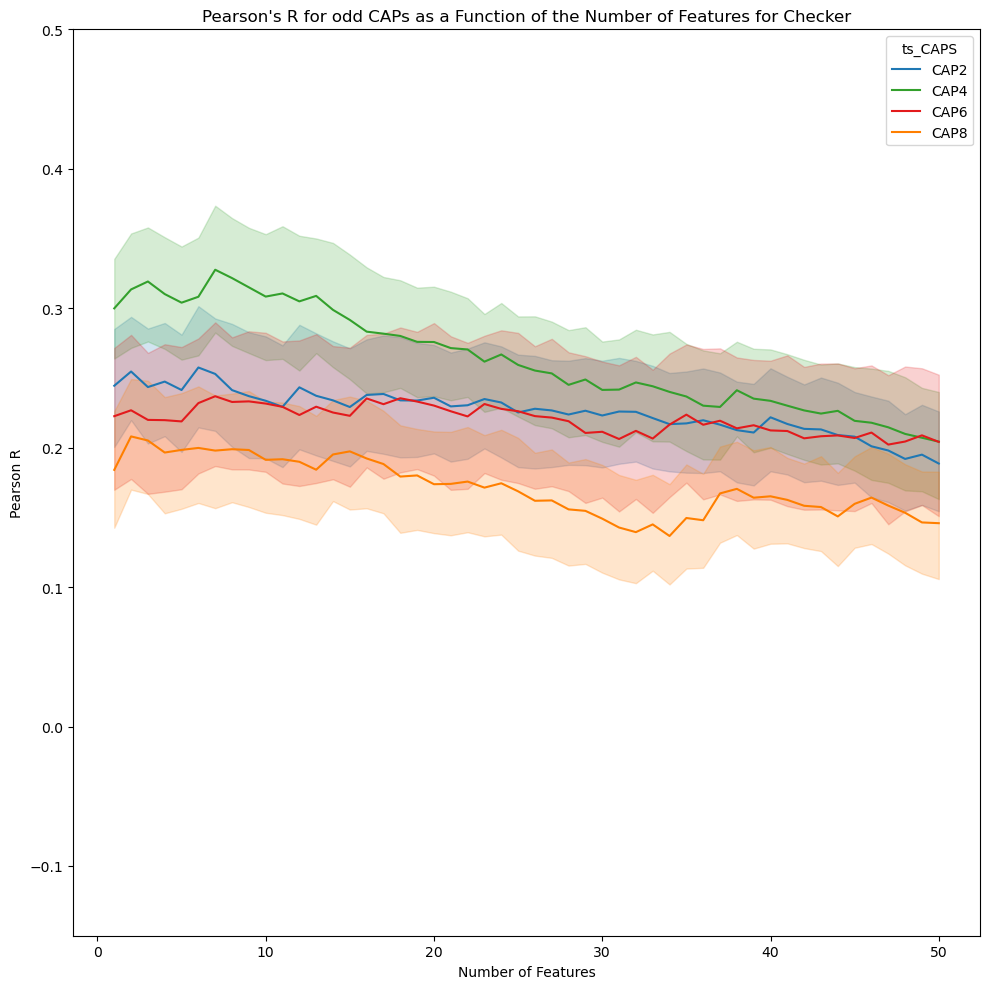

In [10]:
C = "even"
if C == "odd":
    caps = [f'CAP{c}'  for c in range(9) if c%2 != 0]
elif C == "even":
    caps = [f'CAP{c}'  for c in range(9) if c%2 == 0]

petit_pd = gros_pd.groupby(['subject','session','ts_CAPS','n_features']).mean('pearson_r').reset_index()
selected_caps = petit_pd[petit_pd['ts_CAPS'].isin(caps)]
figure = plt.figure(figsize=(10,10))
sns.lineplot(x="n_features", 
             y="pearson_r",
             hue="ts_CAPS",
             data=petit_pd,
             palette="Paired",
             errorbar=('ci', 68),
             #alpha = 1,
             hue_order=[c  if c in caps else '' for c in gros_pd['ts_CAPS'].unique()]
             )
if TASK == 'rest':
    t = "Resting State"
else:
    t = TASK.capitalize()
plt.title(f"Pearson's R for odd CAPs as a Function of the Number of Features for {t}")
plt.ylabel('Pearson R')
plt.xlabel('Number of Features')

plt.ylim(-0.15,0.5)
plt.tight_layout()
plt.savefig(f"/home/slouviot/01_projects/eeg_brain_state_prediction/figures/custom_bands_features_investigation/double_dipping/prediction_as_function_nb_features_{C}_task-{TASK}_with_pupil.png")

In [5]:
gros_pd

,index,subject,session,ts_CAPS,pearson_r,frequency_Hz,electrode,n_features,task,description
0,0,1,1,CAP1,0.406108,[3],[60],1,rest,CustomEnvBk8Caps
1,1,1,1,CAP2,0.383903,[3],[60],1,rest,CustomEnvBk8Caps
2,2,1,1,CAP3,-0.058374,[8],[58],1,rest,CustomEnvBk8Caps
3,3,1,1,CAP4,0.059902,[8],[58],1,rest,CustomEnvBk8Caps
4,4,1,1,CAP5,0.154463,[14],[25],1,rest,CustomEnvBk8Caps
...,...,...,...,...,...,...,...,...,...,...
795,795,14,2,CAP4,-0.028833,[ 8 8 9 8 7 10 7 8 7 7 19 8 11 7 9 ...,[58 9 58 15 9 58 58 44 44 19 9 8 58 8 9 ...,50,rest,CustomEnvBk8Caps
796,796,14,2,CAP5,0.104895,[14 14 15 13 16 15 14 12 11 14 12 11 13 13 2 ...,[25 53 53 25 53 10 10 11 11 46 52 52 46 40 60 ...,50,rest,CustomEnvBk8Caps
797,797,14,2,CAP6,0.117807,[16 14 15 13 14 14 12 11 15 12 14 11 13 15 3 ...,[53 25 53 25 53 10 11 11 10 52 46 52 46 25 16 ...,50,rest,CustomEnvBk8Caps
798,798,14,2,CAP7,0.184179,[ 3 2 2 12 11 10 2 3 2 2 3 4 3 2 3 ...,[16 59 1 52 52 52 7 7 23 0 38 16 1 38 59 ...,50,rest,CustomEnvBk8Caps


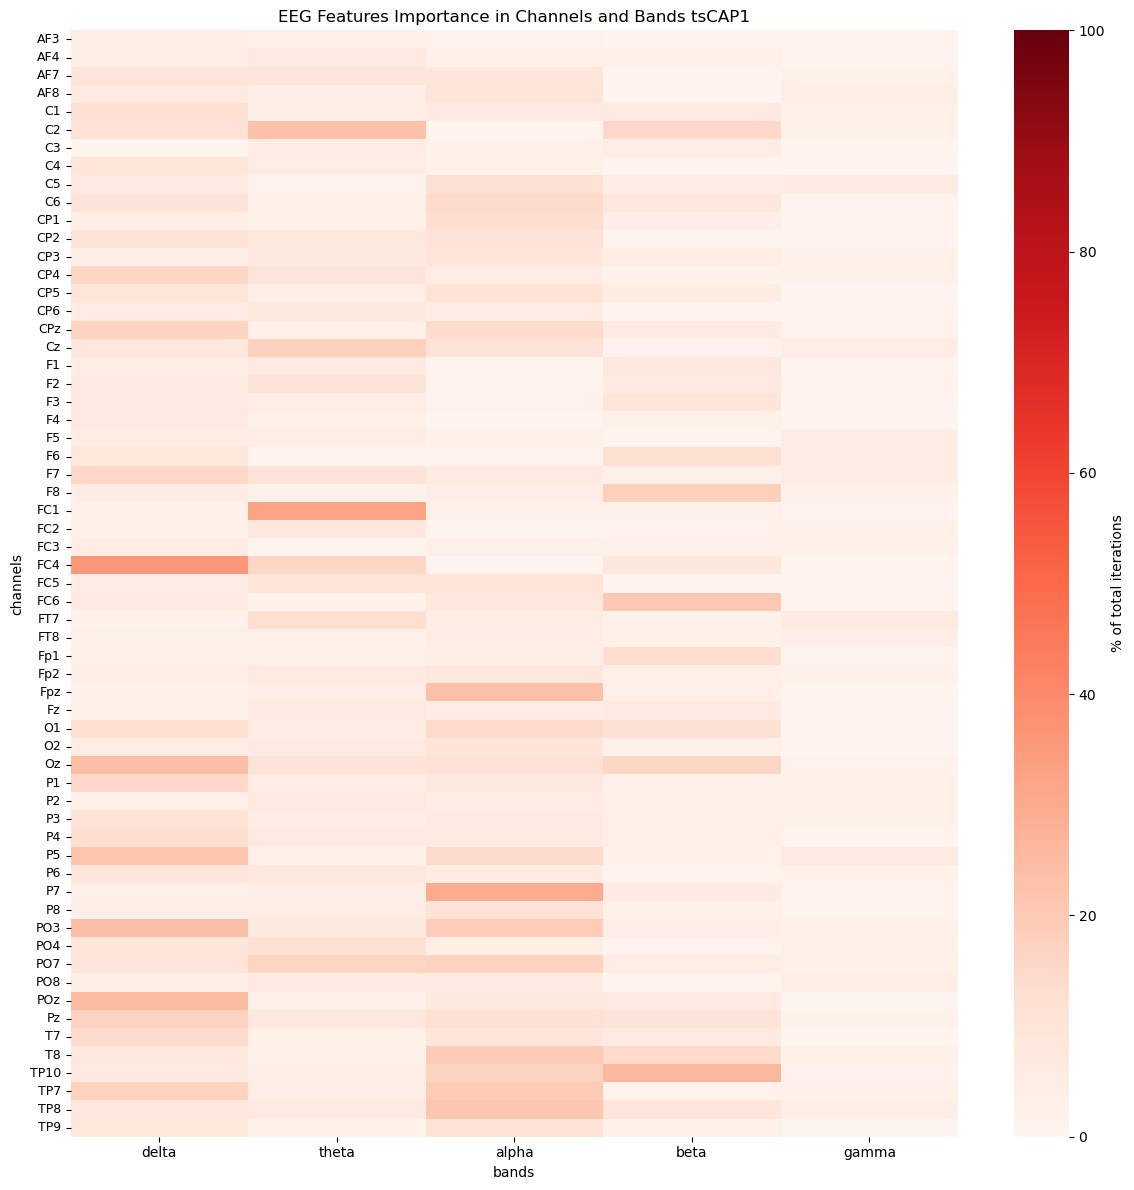

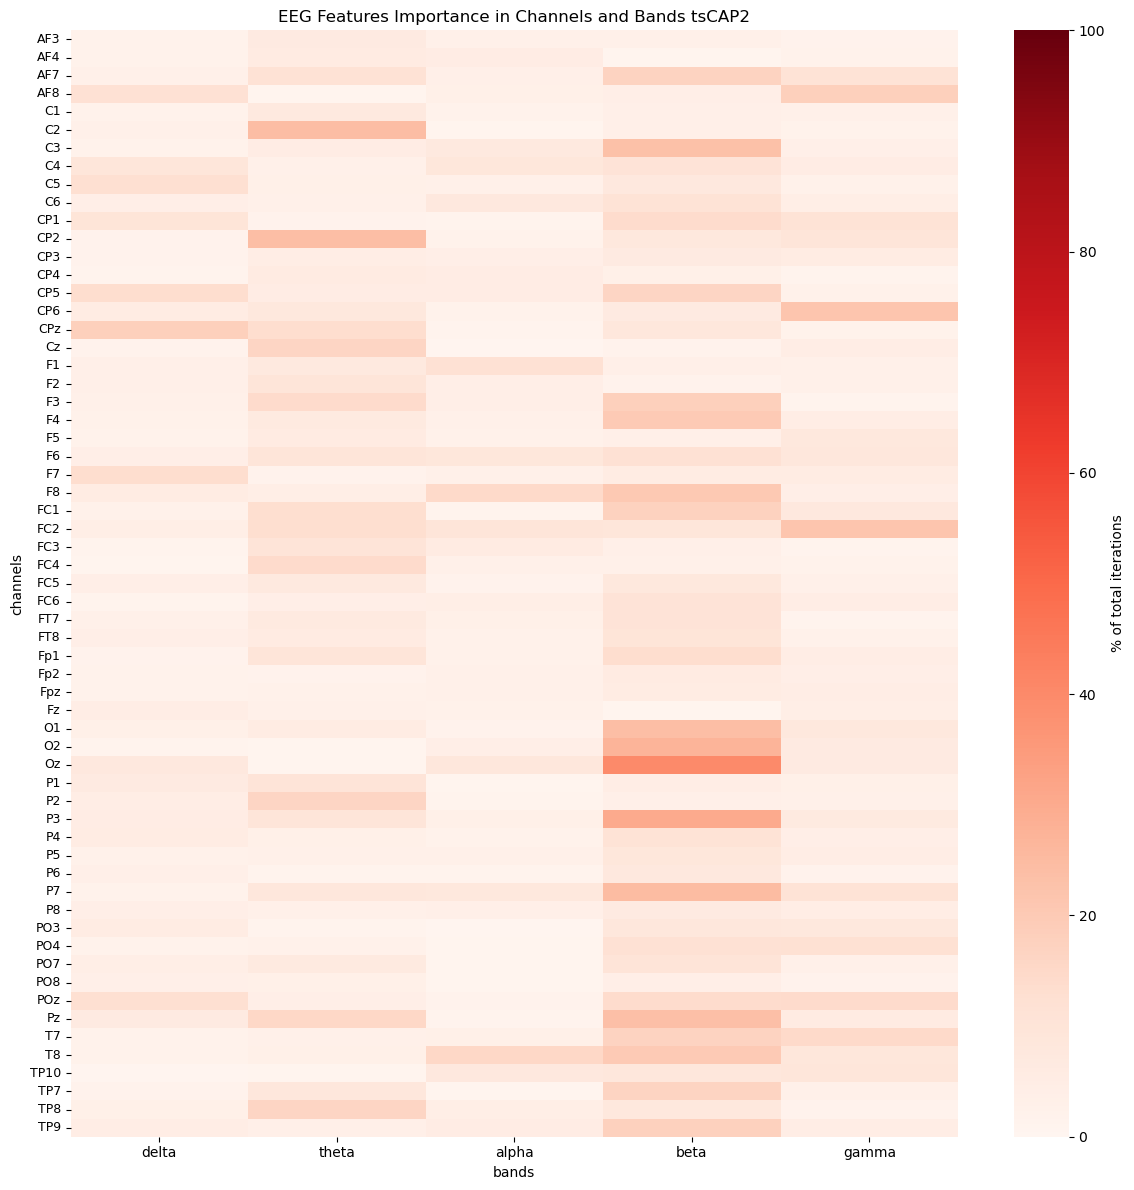

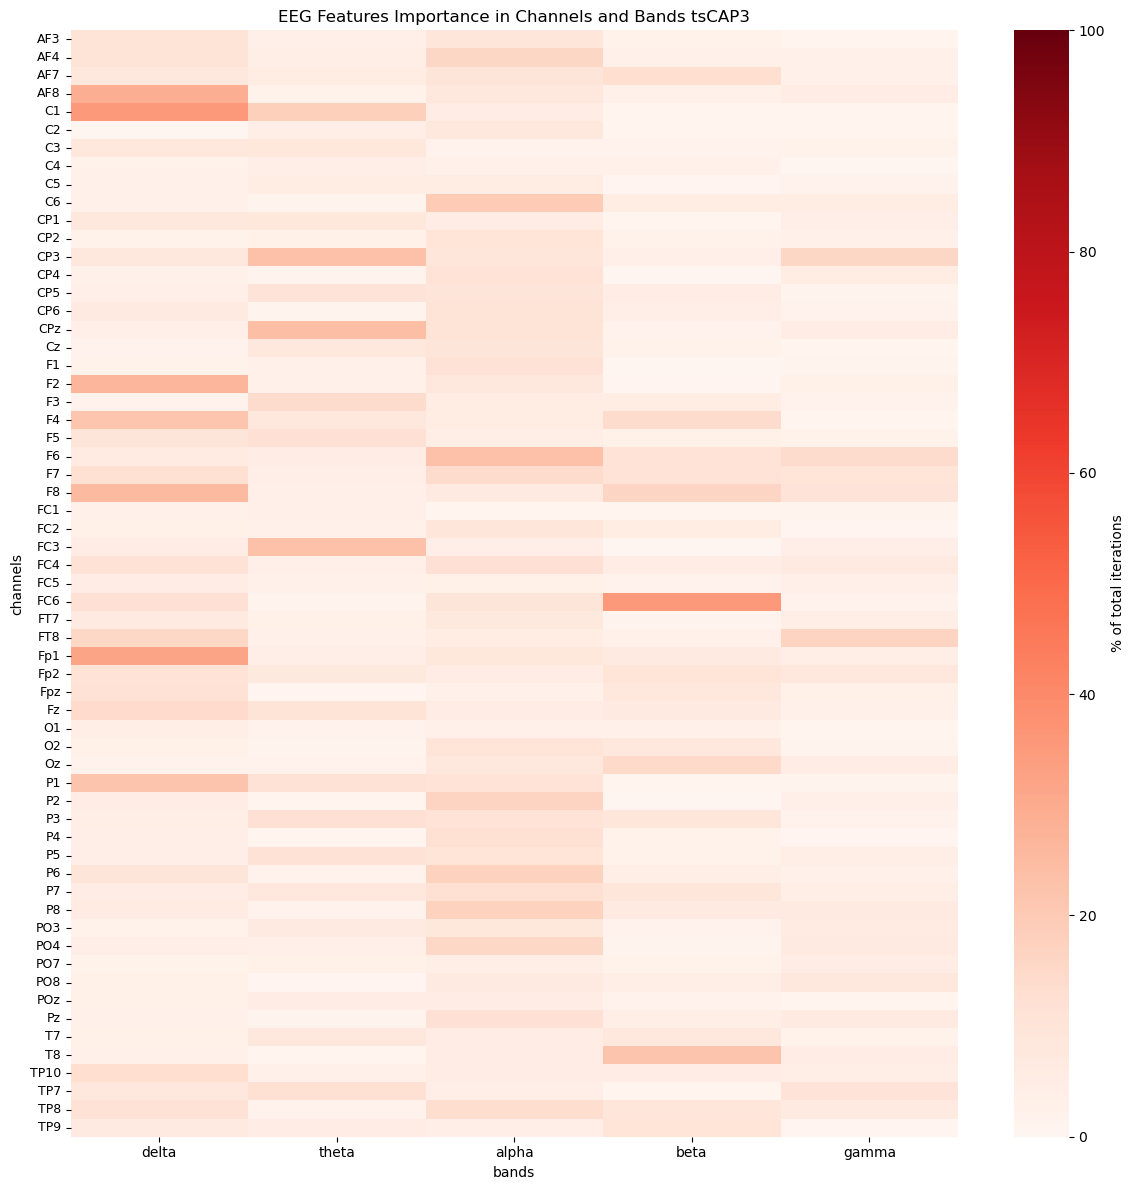

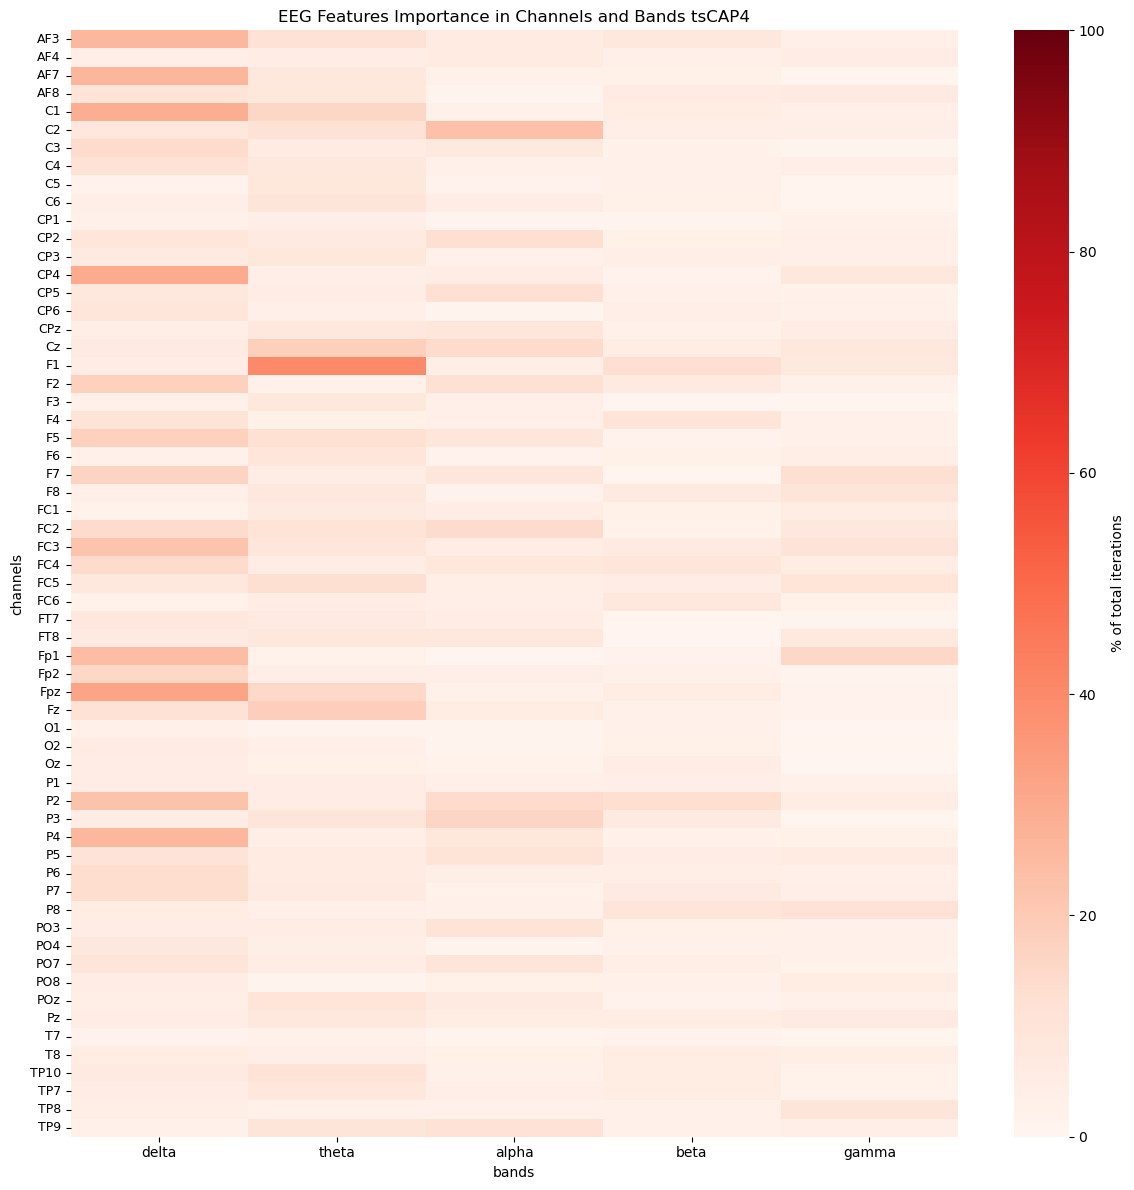

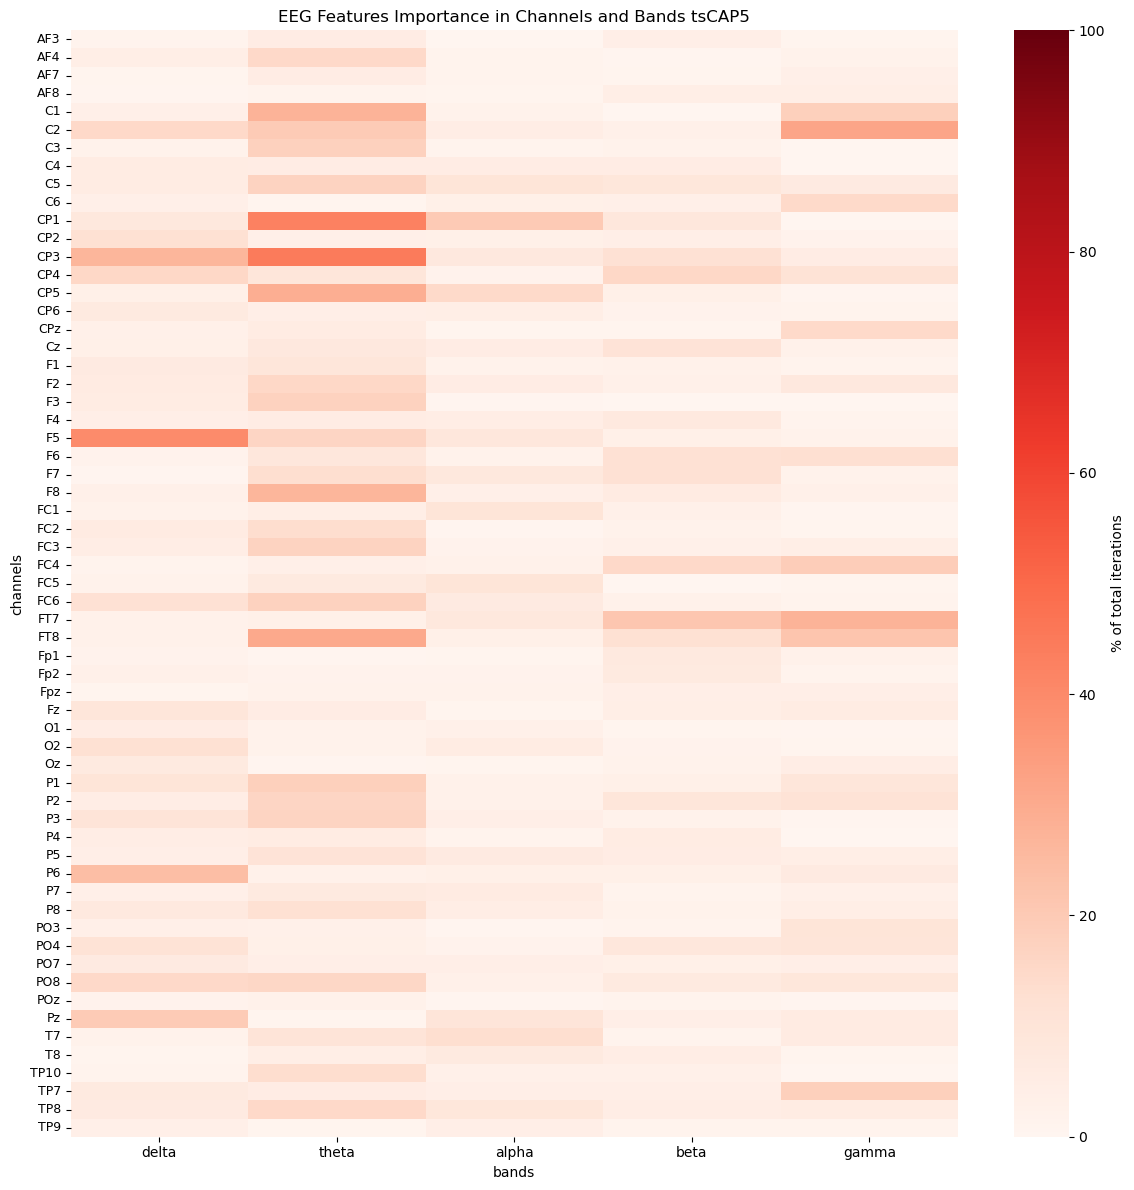

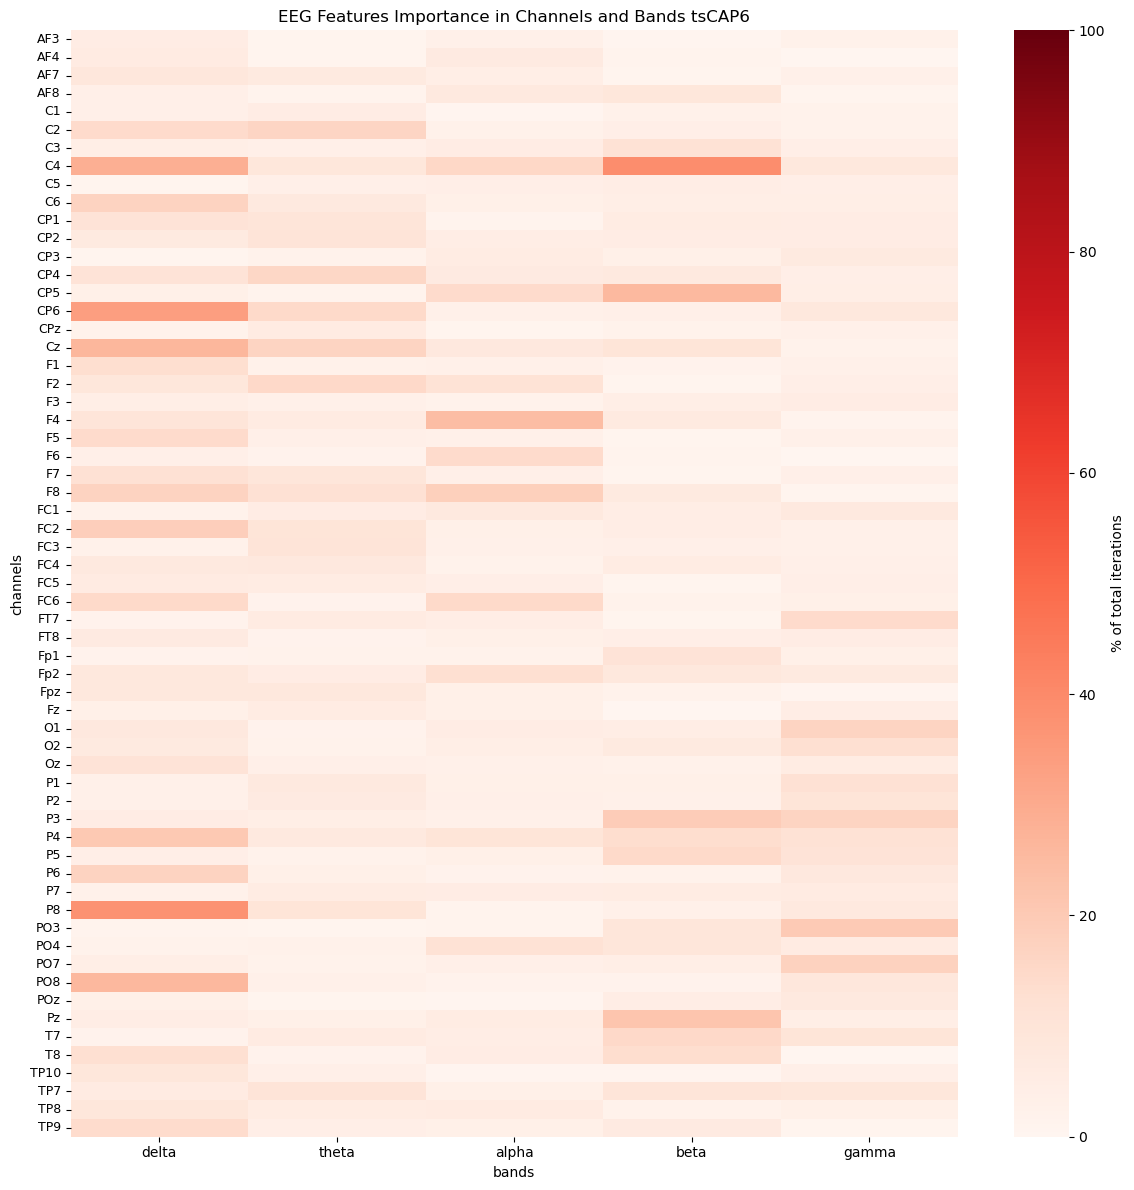

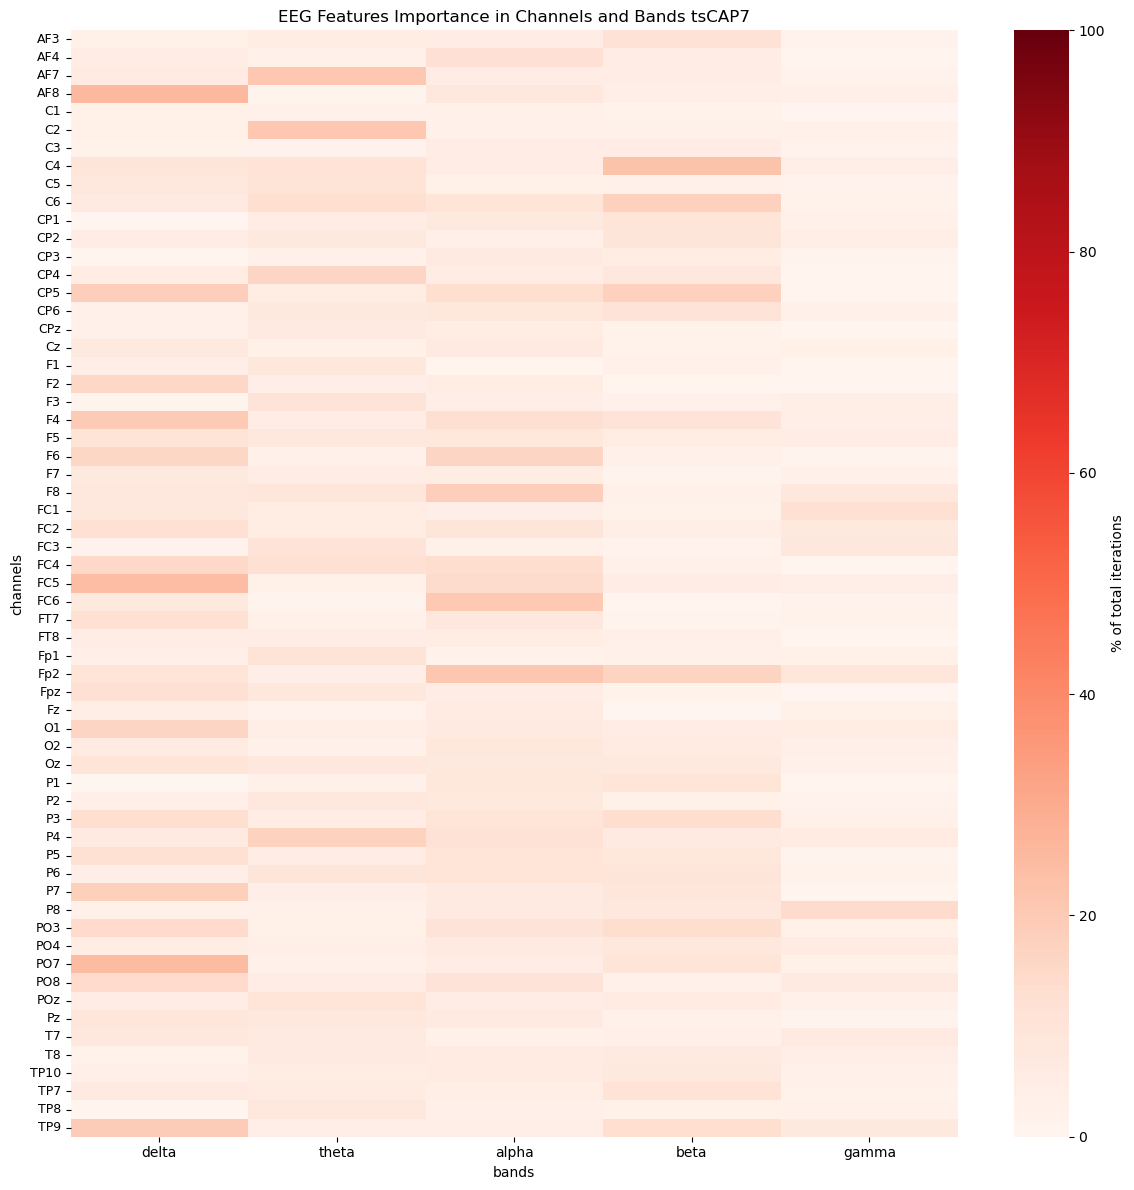

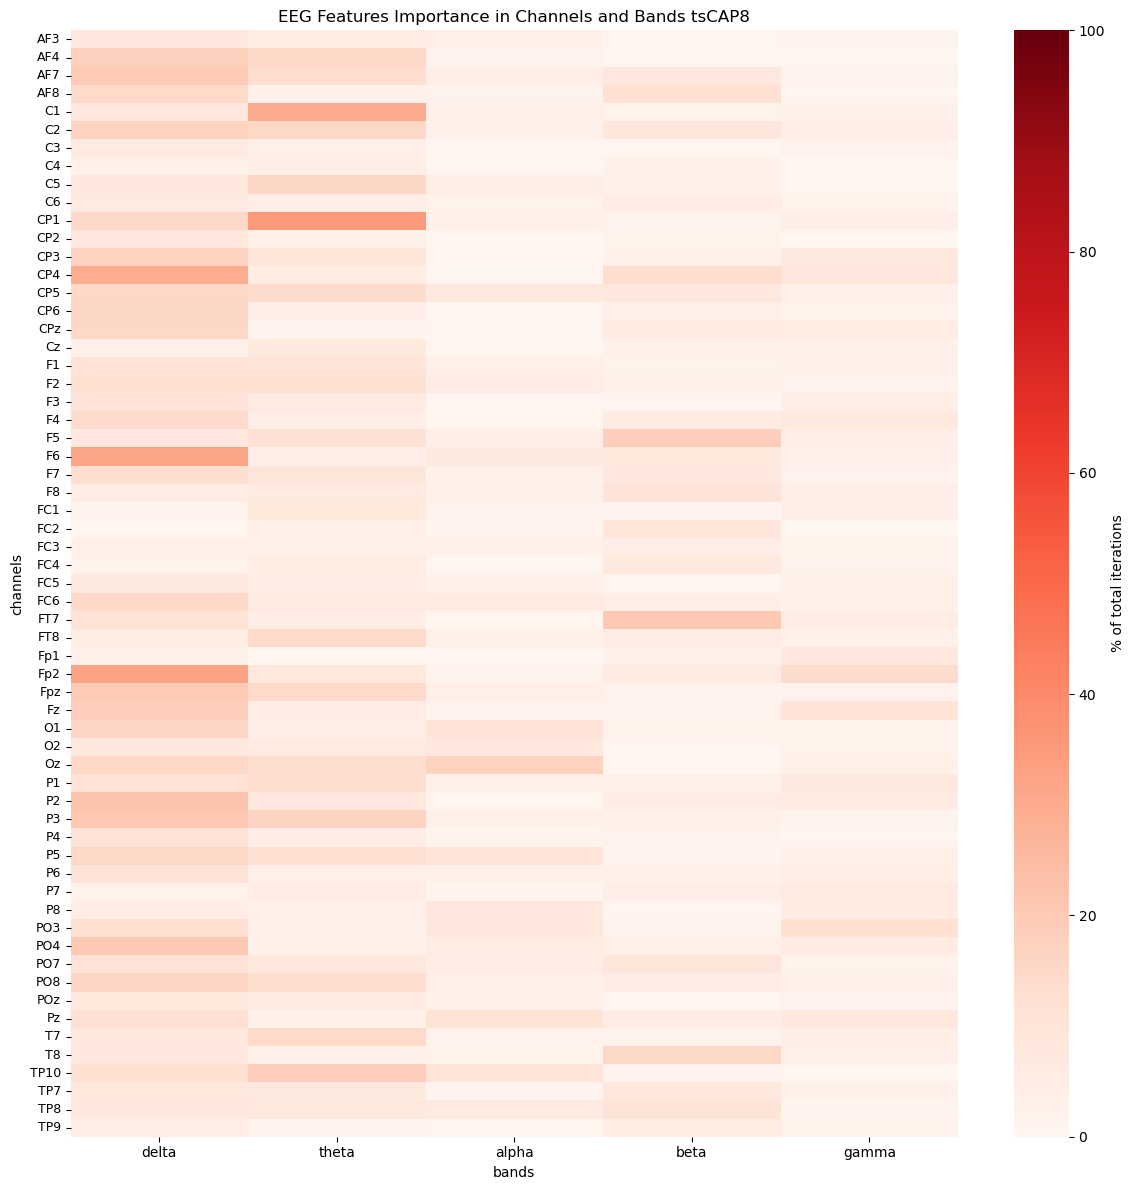

In [10]:
import numpy as np
for cap in gros_pd['ts_CAPS'].unique():
    petit_pd2 = gros_pd.loc[gros_pd['ts_CAPS'] == cap, ['eye_features','eeg_features_channel','eeg_features_band']]
    petit_pd2 = petit_pd2.dropna(axis = 0)
    all_channels = petit_pd2.eeg_features_channel.apply(lambda x: x[1:-1].replace("'","").replace(" ","").split(',') if x is not np.nan else [np.nan]).values
    all_bands = petit_pd2.eeg_features_band.apply(lambda x: x[1:-1].replace("'","").replace(" ","").split(',') if x is not np.nan else [np.nan]).values
    all_channels = np.concatenate(all_channels)
    all_bands = np.concatenate(all_bands)
    dict_for_df = {'channels':all_channels,
                'bands': all_bands}
    eeg_df = pd.DataFrame(dict_for_df)
    pivoted = eeg_df.groupby('bands').value_counts().to_frame().reset_index().pivot(
        columns = 'bands', 
        index = 'channels', 
        values = 'count',
                            ) * 100 / (64 * 28 * 10)
    figure = plt.figure(figsize=(12,12))
    sns.heatmap(pivoted.loc[:,['delta','theta','alpha','beta','gamma']],
                #xticklabels=['delta','theta','alpha','beta','gamma'],
                cmap = 'Reds',
                cbar_kws={'label':'% of total iterations',
                          },
                vmin = 0,
                vmax = 100
                )
    plt.yticks(fontsize = 9)
    plt.title(f'EEG Features Importance in Channels and Bands {cap}')
    plt.tight_layout()
    plt.savefig(f'../figures/eeg_features_importance_{cap}.png')

In [7]:
gros_pd

,index,iteration,subject,session,run,task,ts_CAPS,pearson_r,eye_features,eeg_features_channel,eeg_features_band,nb_features
0,0,1,sub-01,ses-01,run-01,task-checker,tsCAP1,0.622747,['pupil_dilation'],NaN,NaN,1
1,1,1,sub-01,ses-01,run-01,task-checker,tsCAP2,0.499358,['first_derivative'],NaN,NaN,1
2,2,1,sub-01,ses-01,run-01,task-checker,tsCAP3,0.227599,['first_derivative'],NaN,NaN,1
3,3,1,sub-01,ses-01,run-01,task-checker,tsCAP4,0.378649,['pupil_dilation'],NaN,NaN,1
4,4,1,sub-01,ses-01,run-01,task-checker,tsCAP5,0.303291,['first_derivative'],NaN,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...
2155,2155,10,sub-22,ses-02,run-01,task-checker,tsCAP6,0.254941,"['pupil_dilation', 'second_derivative', 'first...","['CP5', 'F4', 'C3', 'PO4', 'CP5', 'C3', 'POz',...","['alpha', 'alpha', 'alpha', 'alpha', 'gamma', ...",28
2156,2156,10,sub-22,ses-01,run-01,task-checker,tsCAP7,-0.004938,"['pupil_dilation', 'first_derivative', 'second...","['P3', 'CP1', 'CP2', 'Cz', 'P8', 'C4', 'P4', '...","['beta', 'gamma', 'gamma', 'beta', 'gamma', 'g...",28
2157,2157,10,sub-22,ses-02,run-01,task-checker,tsCAP7,0.167144,"['pupil_dilation', 'first_derivative', 'second...","['P3', 'CP1', 'CP2', 'Cz', 'P8', 'C4', 'P4', '...","['beta', 'gamma', 'gamma', 'beta', 'gamma', 'g...",28
2158,2158,10,sub-22,ses-01,run-01,task-checker,tsCAP8,-0.126097,"['pupil_dilation', 'first_derivative', 'second...","['Fp1', 'F4', 'F3', 'C3', 'FC6', 'F5', 'P7', '...","['gamma', 'gamma', 'gamma', 'gamma', 'gamma', ...",28


In [6]:
1000*100/(64 * 10 * 27) 

5.787037037037037

In [4]:
gros_pd[gros_pd['ts_CAPS'] == 'tsCAP1'].groupby(['subject','session']).mean('pearson_r').reset_index()

,subject,session,index,iteration,pearson_r,nb_features
0,sub-01,ses-01,0.000,10.0,0.464166,32.5
1,sub-02,ses-01,8.000,10.0,0.312473,32.5
2,sub-03,ses-01,16.000,10.0,0.963188,2.0
3,sub-05,ses-02,16.375,10.0,0.068786,32.5
4,sub-06,ses-01,24.375,10.0,0.188104,32.5
5,sub-06,ses-02,25.375,10.0,0.195728,32.5
6,sub-07,ses-01,40.375,10.0,0.205171,32.5
7,sub-07,ses-02,41.375,10.0,0.317275,32.5
8,sub-08,ses-01,56.375,10.0,-0.059265,32.5
9,sub-08,ses-02,57.375,10.0,0.247444,32.5


In [9]:
all_eyes = petit_pd2.eye_features.apply(lambda x: x[1:-1].replace("'","").replace(" ","").split(',')).values()

In [13]:
all_eyes = np.concatenate(all_eyes)
df_all_eyes = pd.DataFrame({'eye_features':all_eyes})


In [15]:
df_all_eyes.value_counts().reset_index().pivot(columns = 'eye_features')

count                                 
eye_features first_derivative pupil_dilation second_derivative
0                      5032.0            NaN               NaN
1                         NaN         5032.0               NaN
2                         NaN            NaN            5032.0

,eye_features
0,pupil_dilation
1,first_derivative
2,second_derivative
3,pupil_dilation
4,first_derivative
...,...
15091,second_derivative
15092,first_derivative
15093,pupil_dilation
15094,second_derivative
